In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\mrbha\Downloads\titanic\train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.shape

(891, 12)

In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [8]:
df.drop("Cabin", axis=1, inplace=True)

In [9]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [10]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [11]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [12]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [13]:
#FEATURE ENGINEERING

In [14]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [15]:
df[["SibSp", "Parch", "FamilySize"]].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [16]:
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

In [17]:
df[["FamilySize", "IsAlone"]].head(10)

,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1
5,1,1
6,1,1
7,5,0
8,3,0
9,2,0


In [18]:
df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)

In [19]:
df[["Name", "Title"]].head()

,Name,Title
0,"Braund, Mr. Owen Harris",Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs
2,"Heikkinen, Miss. Laina",Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs
4,"Allen, Mr. William Henry",Mr


In [20]:
df["Title"].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64

In [21]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone",
    "Title"
]

In [22]:
X = df[features]
y = df["Survived"]

In [23]:
numeric_features = [
    "Age",
    "Fare",
    "FamilySize"
]

In [24]:
categorical_features = [
    "Sex",
    "Embarked",
    "Title",
    "Pclass"
]

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [26]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

In [27]:
categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 8)
(179, 8)
(712,)
(179,)


In [31]:
from sklearn.linear_model import LogisticRegression

In [32]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

In [33]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare',
                                                   'FamilySize']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked', 'Title',
                                                   'Pclass'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [34]:
y_pred = model.predict(X_test)

In [35]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [36]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8100558659217877


In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.84      0.84       105
           1       0.77      0.77      0.77        74

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [38]:
print(confusion_matrix(y_test, y_pred))

[[88 17]
 [17 57]]


In [39]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Accuracy: 0.8324022346368715
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       105
           1       0.80      0.80      0.80        74

    accuracy                           0.83       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.83      0.83      0.83       179



In [40]:
from sklearn.tree import DecisionTreeClassifier

dt_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, dt_pred))

Accuracy: 0.7486033519553073


In [41]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", KNeighborsClassifier(n_neighbors=5))
    ]
)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, knn_pred))

Accuracy: 0.8044692737430168


In [42]:
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred),
    "Decision Tree": accuracy_score(y_test, dt_pred),
    "Random Forest": accuracy_score(y_test, rf_pred),
    "KNN": accuracy_score(y_test, knn_pred)
}

for model, score in results.items():
    print(f"{model}: {score:.4f}")

Logistic Regression: 0.8101
Decision Tree: 0.7486
Random Forest: 0.8324
KNN: 0.8045


In [43]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [3, 5, 10, None]
}

grid = GridSearchCV(
    rf_model,
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'classifier__max_depth': 5, 'classifier__n_estimators': 200}
0.8342263370432385


In [44]:
import joblib

joblib.dump(grid.best_estimator_, "titanic_model.pkl")

['titanic_model.pkl']

In [45]:
model = joblib.load("titanic_model.pkl")

In [46]:
import pandas as pd

df = pd.read_csv(r"C:\Users\mrbha\Downloads\titanic\test.csv")

df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [48]:
df.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [49]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [50]:
df["Fare"] = df["Fare"].fillna(df["Fare"].median())

In [51]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [52]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [53]:
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

In [54]:
df["Title"] = df["Name"].str.extract(
    r" ([A-Za-z]+)\.",
    expand=False
)

In [55]:
X_final = df[features]

In [56]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [57]:
print(df.columns.tolist())

['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'FamilySize', 'IsAlone', 'Title']


In [58]:
print(features)

['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title']


In [59]:
for col in features:
    if col not in df.columns:
        print(col, "is missing")

In [60]:
print(X_final.head())

   Pclass     Sex   Age     Fare Embarked  FamilySize  IsAlone Title
0       3    male  34.5   7.8292        Q           1        1    Mr
1       3  female  47.0   7.0000        S           2        0   Mrs
2       2    male  62.0   9.6875        Q           1        1    Mr
3       3    male  27.0   8.6625        S           1        1    Mr
4       3  female  22.0  12.2875        S           3        0   Mrs


In [61]:
predictions = model.predict(X_final)

In [62]:
print(predictions[:10])

[0 1 0 0 1 0 1 0 1 0]


In [63]:
submission = pd.DataFrame({
    "PassengerId": df["PassengerId"],
    "Survived": predictions
})

In [64]:
#VISUALIZATION

In [65]:
import matplotlib as plt
import seaborn as sns

In [66]:
# ===============================
# Data Manipulation
# ===============================
import pandas as pd
import numpy as np

# ===============================
# Data Visualization
# ===============================
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: Better plot appearance
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Display all columns (optional)
pd.set_option("display.max_columns", None)

In [67]:
# Statistical plots
from scipy import stats

# Confusion Matrix Display
from sklearn.metrics import ConfusionMatrixDisplay

# ROC Curve
from sklearn.metrics import RocCurveDisplay

# Precision-Recall Curve
from sklearn.metrics import PrecisionRecallDisplay

# Tree visualization (Decision Tree)
from sklearn.tree import plot_tree

In [68]:
print(df.columns.tolist())

['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'FamilySize', 'IsAlone', 'Title']


In [69]:
df.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked', 'FamilySize', 'IsAlone',
       'Title'],
      dtype='object')

In [70]:
df = pd.read_csv(r"C:\Users\mrbha\Downloads\titanic\train.csv")

In [71]:
print(df.shape)
print(df.columns.tolist())

(891, 12)
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


<Axes: xlabel='Survived', ylabel='count'>

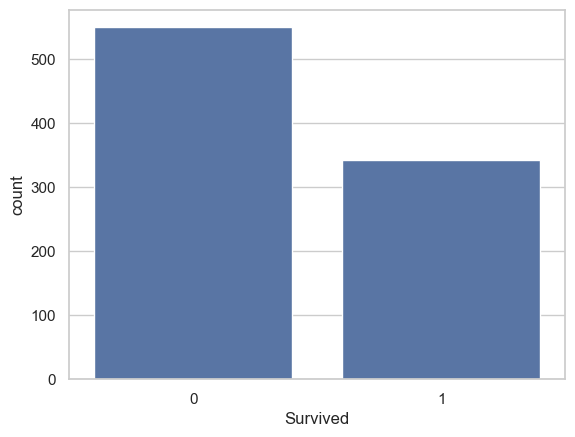

In [72]:
sns.countplot(x="Survived", data=df)

<Axes: xlabel='Sex', ylabel='count'>

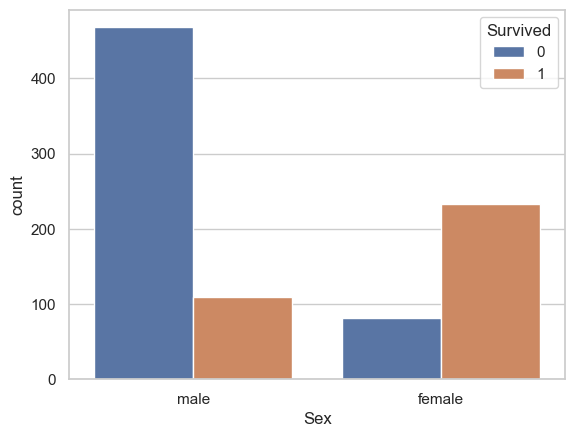

In [73]:
sns.countplot(x="Sex", hue="Survived", data=df)

<Axes: xlabel='Pclass', ylabel='count'>

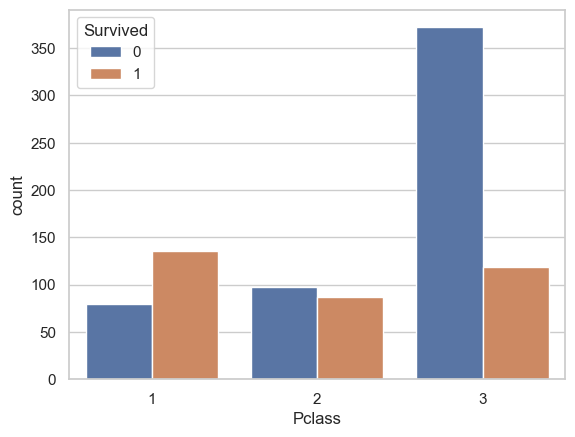

In [74]:
sns.countplot(x="Pclass", hue="Survived", data=df)

<Axes: xlabel='Age', ylabel='Count'>

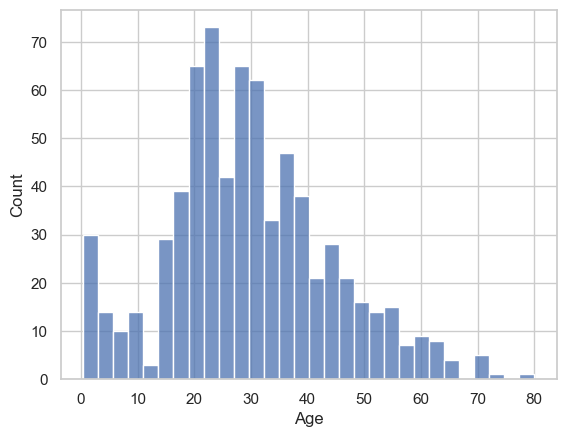

In [75]:
sns.histplot(df["Age"], bins=30)

<Axes: xlabel='Fare', ylabel='Count'>

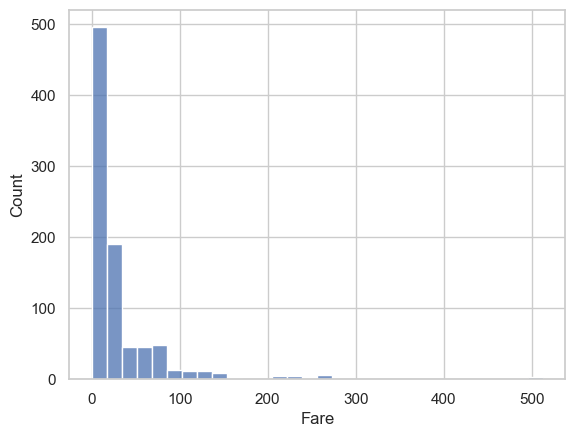

In [76]:
sns.histplot(df["Fare"], bins=30)

<Axes: xlabel='Survived', ylabel='Age'>

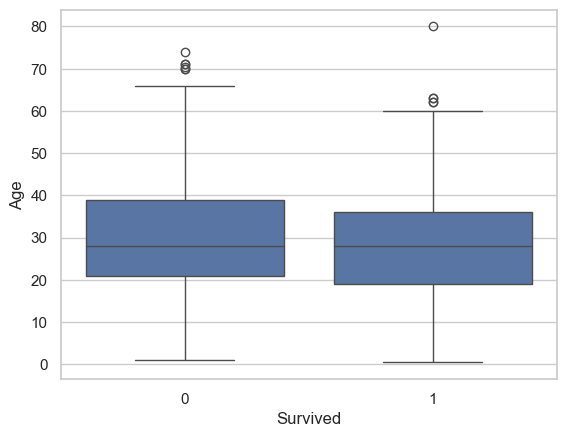

In [77]:
sns.boxplot(x="Survived", y="Age", data=df)

<Axes: xlabel='Pclass', ylabel='Fare'>

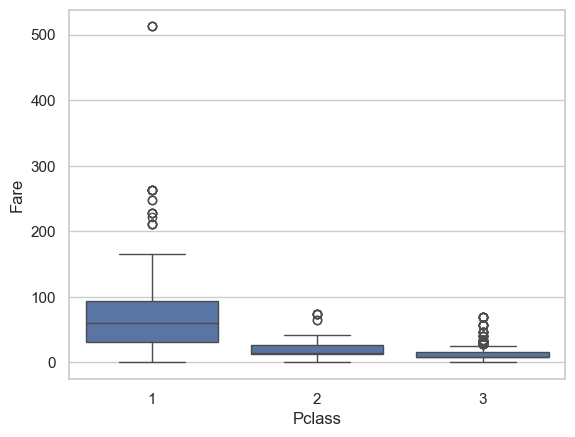

In [78]:
sns.boxplot(x="Pclass", y="Fare", data=df)

<Axes: >

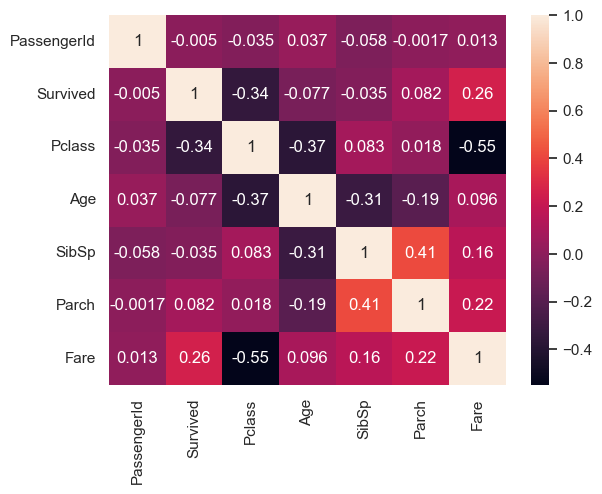

In [79]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [80]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)

In [81]:
df["FareGroup"] = pd.qcut(
    df["Fare"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

In [82]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [83]:
print(df[["SibSp", "Parch", "FamilySize"]].head())

   SibSp  Parch  FamilySize
0      1      0           2
1      1      0           2
2      0      0           1
3      1      0           2
4      0      0           1


In [84]:
def family_category(size):
    if size == 1:
        return "Alone"
    elif size <= 4:
        return "Small"
    else:
        return "Large"

df["FamilyCategory"] = df["FamilySize"].apply(family_category)

<Axes: xlabel='AgeGroup', ylabel='count'>

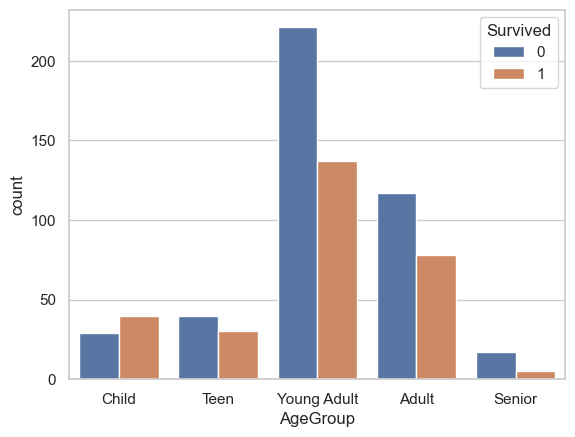

In [85]:
sns.countplot(x="AgeGroup", hue="Survived", data=df)

<Axes: xlabel='FareGroup', ylabel='count'>

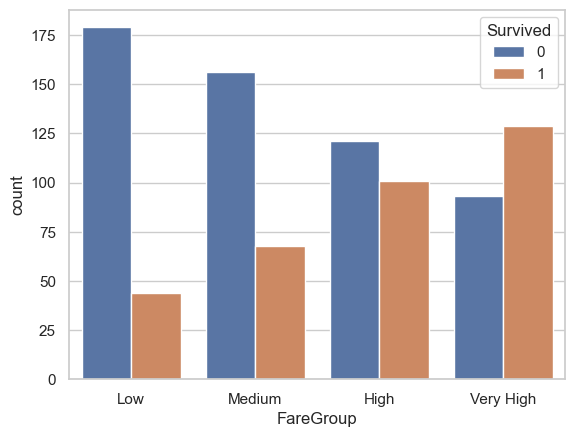

In [86]:
sns.countplot(x="FareGroup", hue="Survived", data=df)

<Axes: xlabel='FamilyCategory', ylabel='count'>

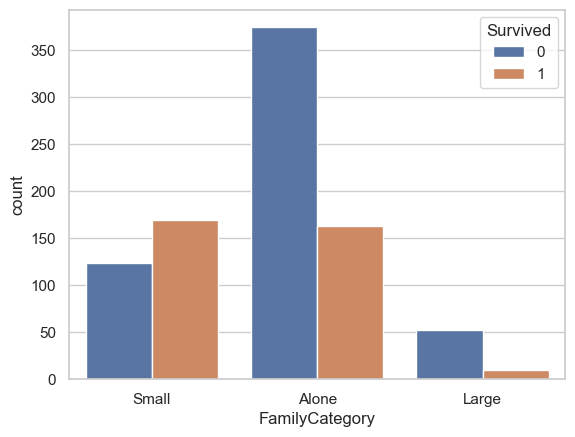

In [87]:
sns.countplot(x="FamilyCategory", hue="Survived", data=df)

In [88]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [89]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

In [90]:
dt_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]
)

In [91]:
dt_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare',
                                                   'FamilySize']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked', 'Title',
                                                   'Pclass'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [92]:
dt_pred = dt_model.predict(X_test)

In [93]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, dt_pred)

print(dt_accuracy)

0.7486033519553073


In [94]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

In [95]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare',
                                                   'FamilySize']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked', 'Title',
                                                   'Pclass'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [96]:
rf_pred = rf_model.predict(X_test)

In [97]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print(rf_accuracy)

0.8324022346368715


In [98]:
knn_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", KNeighborsClassifier(
            n_neighbors=5
        ))
    ]
)

In [99]:
knn_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare',
                                                   'FamilySize']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked', 'Title',
                                                   'Pclass'])])),
                ('classifier', KNeighborsClassifier())])

In [100]:
knn_pred = knn_model.predict(X_test)

In [101]:
knn_accuracy = accuracy_score(y_test, knn_pred)

print(knn_accuracy)

0.8044692737430168


In [102]:
svm_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", SVC())
    ]
)

In [103]:
svm_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare',
                                                   'FamilySize']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked', 'Title',
                                                   'Pclass'])])),
                ('classifier', SVC())])

In [104]:
svm_pred = svm_model.predict(X_test)

In [105]:
svm_accuracy = accuracy_score(y_test, svm_pred)

print(svm_accuracy)

0.8268156424581006


In [106]:
results = {
    "Logistic Regression": accuracy,
    "Decision Tree": dt_accuracy,
    "Random Forest": rf_accuracy,
    "KNN": knn_accuracy,
    "SVM": svm_accuracy
}

comparison = pd.DataFrame(
    results.items(),
    columns=["Model", "Accuracy"]
)

comparison

,Model,Accuracy
0,Logistic Regression,0.810056
1,Decision Tree,0.748603
2,Random Forest,0.832402
3,KNN,0.804469
4,SVM,0.826816


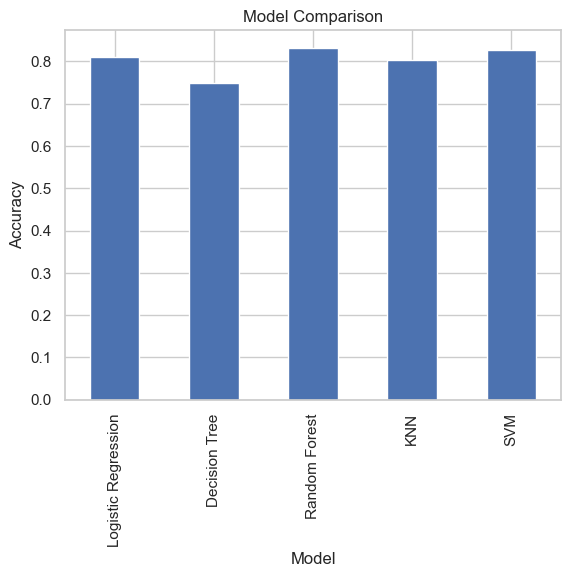

In [107]:
import matplotlib.pyplot as plt

comparison.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    legend=False
)

plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

In [108]:
# Hyperparameter Tuning #

In [109]:
from sklearn.model_selection import GridSearchCV

In [110]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42))
    ]
)

In [111]:
param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [5, 10, 15, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

In [112]:
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [113]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'Fare',
                                                                          'FamilySize']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Sex',
                                                                          'Embarked',
                                                                          'Title',
                                                                          'Pclass'])])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [5, 10, 15, None],
                         'classifier__min_samples_leaf': [1, 2, 4],
                         'classifier__min_samples_split': [2, 5, 10],
                         'classifier__n_estimators': [100, 200, 300]},
             scoring='accuracy')

In [114]:
print(grid_search.best_params_)

{'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}


In [115]:
{
    'classifier__max_depth': 10,
    'classifier__min_samples_leaf': 2,
    'classifier__min_samples_split': 5,
    'classifier__n_estimators': 200
}

{'classifier__max_depth': 10,
 'classifier__min_samples_leaf': 2,
 'classifier__min_samples_split': 5,
 'classifier__n_estimators': 200}

In [116]:
print(grid_search.best_score_)

0.8370333891460652


In [117]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

In [118]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

Test Accuracy: 0.8268156424581006


In [119]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86       105
           1       0.82      0.74      0.78        74

    accuracy                           0.83       179
   macro avg       0.83      0.81      0.82       179
weighted avg       0.83      0.83      0.83       179



In [120]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[93 12]
 [19 55]]


In [121]:
from sklearn.model_selection import cross_val_score

In [122]:
best_model = grid_search.best_estimator_

In [123]:
best_model = rf_model

In [124]:
cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

In [125]:
print(cv_scores)

[0.7877095  0.79775281 0.85393258 0.7752809  0.81460674]


In [126]:
print("Mean Accuracy:", cv_scores.mean())

Mean Accuracy: 0.8058565061829137


In [127]:
print("Standard Deviation:", cv_scores.std())

Standard Deviation: 0.027268030764045586


In [128]:
import pandas as pd

cv_results = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Accuracy": cv_scores
})

cv_results

,Fold,Accuracy
0,1,0.787709
1,2,0.797753
2,3,0.853933
3,4,0.775281
4,5,0.814607


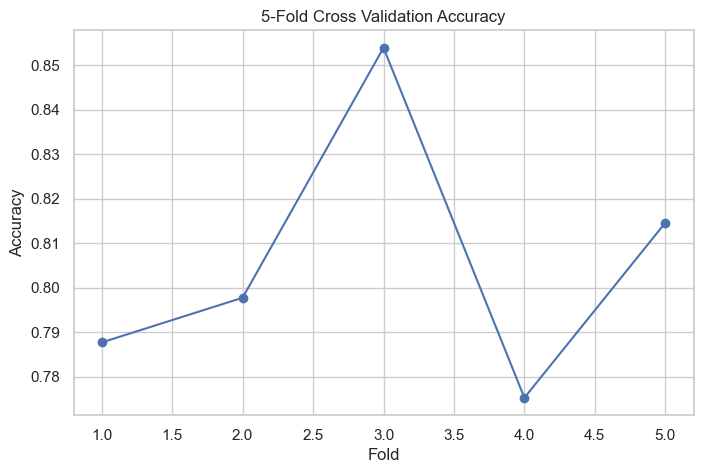

In [129]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(cv_results["Fold"], cv_results["Accuracy"], marker="o")

plt.title("5-Fold Cross Validation Accuracy")
plt.xlabel("Fold")
plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

In [130]:
from sklearn.model_selection import cross_val_score

In [131]:
best_model = grid_search.best_estimator_

In [132]:
best_model = rf_model

In [133]:
cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

In [134]:
print(cv_scores)

[0.7877095  0.79775281 0.85393258 0.7752809  0.81460674]


In [135]:
print("Mean Accuracy:", cv_scores.mean())

Mean Accuracy: 0.8058565061829137


In [136]:
print("Standard Deviation:", cv_scores.std())

Standard Deviation: 0.027268030764045586


In [137]:
cv_df = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "Accuracy": cv_scores
})

cv_df

,Fold,Accuracy
0,1,0.787709
1,2,0.797753
2,3,0.853933
3,4,0.775281
4,5,0.814607


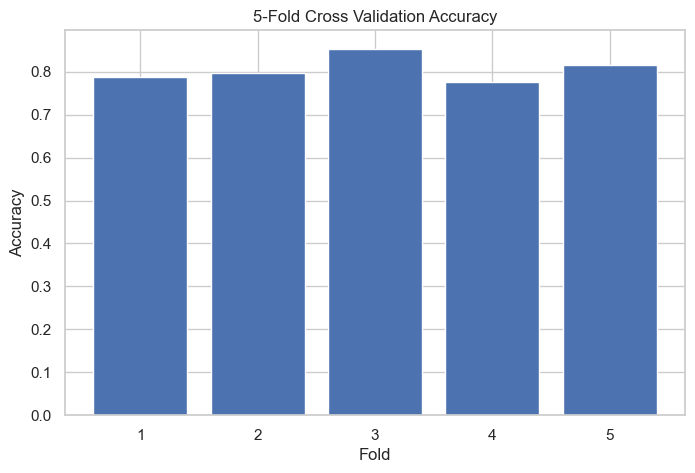

In [138]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(cv_df["Fold"], cv_df["Accuracy"])

plt.title("5-Fold Cross Validation Accuracy")
plt.xlabel("Fold")
plt.ylabel("Accuracy")

plt.show()

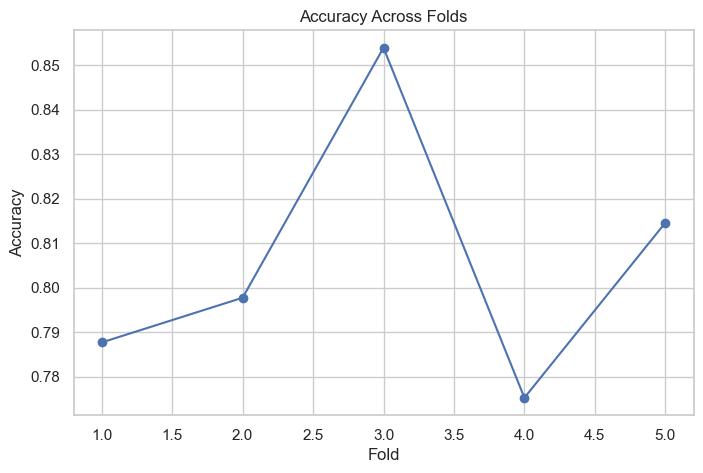

In [139]:
plt.figure(figsize=(8,5))

plt.plot(
    cv_df["Fold"],
    cv_df["Accuracy"],
    marker="o"
)

plt.title("Accuracy Across Folds")
plt.xlabel("Fold")
plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

In [140]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare',
                                                   'FamilySize']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked', 'Title',
                                                   'Pclass'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [141]:
best_model = grid_search.best_estimator_

In [142]:
rf_classifier = best_model.named_steps["classifier"]

In [143]:
importance = rf_classifier.feature_importances_

In [144]:
print(importance)

[5.74085537e-02 9.45258752e-02 6.76751258e-02 1.43838655e-01
 1.61333427e-01 1.13143266e-02 6.92294007e-03 1.33053184e-02
 7.77156254e-04 1.20976435e-03 6.65305432e-05 1.22068095e-03
 3.95288673e-05 1.04805674e-03 1.52709420e-02 3.69116001e-02
 3.29240631e-04 1.43883951e-04 1.93955926e-01 5.68657794e-02
 5.47867234e-05 4.46910585e-03 3.05253239e-02 2.20985820e-02
 7.86888903e-02]


In [145]:
feature_names = best_model.named_steps[
    "preprocessor"
].get_feature_names_out()

In [146]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

In [147]:
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

In [148]:
importance_df.head(10)

,Feature,Importance
18,cat__Title_Mr,0.193956
4,cat__Sex_male,0.161333
3,cat__Sex_female,0.143839
1,num__Fare,0.094526
24,cat__Pclass_3,0.078689
2,num__FamilySize,0.067675
0,num__Age,0.057409
19,cat__Title_Mrs,0.056866
15,cat__Title_Miss,0.036912
22,cat__Pclass_1,0.030525


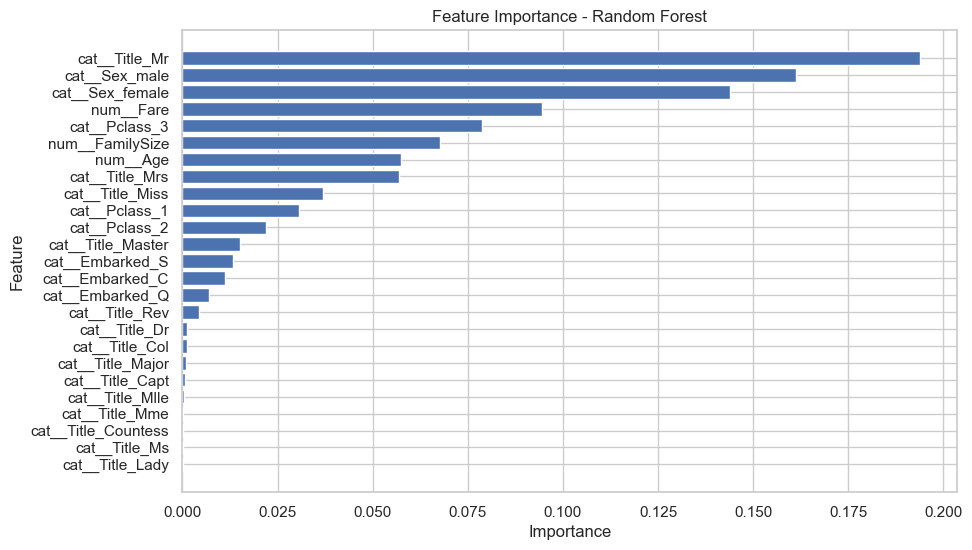

In [149]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest")

plt.gca().invert_yaxis()

plt.show()

In [150]:
from sklearn.metrics import (
    RocCurveDisplay,
    PrecisionRecallDisplay,
    roc_auc_score
)

In [151]:
y_prob = best_model.predict_proba(X_test)[:, 1]

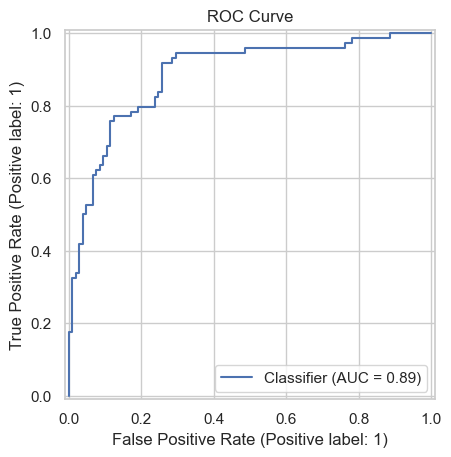

In [152]:
RocCurveDisplay.from_predictions(y_test, y_prob)

plt.title("ROC Curve")
plt.show()

In [153]:
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.8864864864864865


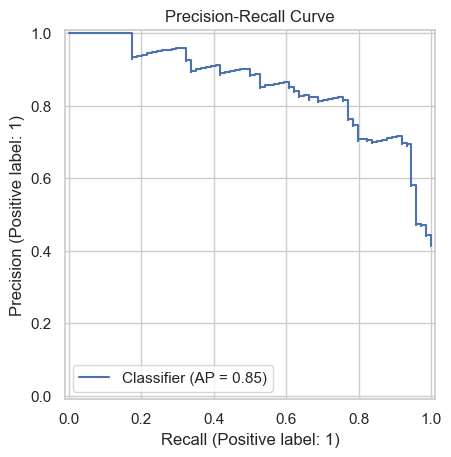

In [154]:
PrecisionRecallDisplay.from_predictions(y_test, y_prob)

plt.title("Precision-Recall Curve")
plt.show()

In [155]:
import joblib

In [156]:
best_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare',
                                                   'FamilySize']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked', 'Title',
                                                   'Pclass'])])),
                ('classifier',
                 RandomForestClassifier(max_depth=5, min_samples_split=5,
                                        n_estimators=200, random_state=42))])

In [157]:
joblib.dump(best_model, "titanic_model.pkl")

['titanic_model.pkl']

In [158]:
loaded_model = joblib.load("titanic_model.pkl")

In [159]:
predictions = loaded_model.predict(X_test)

print(predictions[:10])

[1 0 0 1 1 1 1 0 1 1]


In [160]:
submission.to_csv("submission.csv", index=False)

In [ ]:
pip install shap 

Note: you may need to restart the kernel to use updated packages.


In [162]:
import numpy as np
import shap

print(np.__version__)
print(shap.__version__)

1.26.4
0.46.0


In [163]:
import shap

In [164]:
pip install shap

In [335]:
rf_classifier = best_model.named_steps["classifier"]

In [337]:
X_test_transformed = best_model.named_steps["preprocessor"].transform(X_test)

In [347]:
X_test_dense = X_test_transformed.toarray()

In [349]:
print(type(X_test_dense))
print(X_test_dense.dtype)

<class 'numpy.ndarray'>
float64


In [351]:
explainer = shap.TreeExplainer(best_model.named_steps["classifier"])

In [353]:
shap_values = explainer.shap_values(X_test_dense)

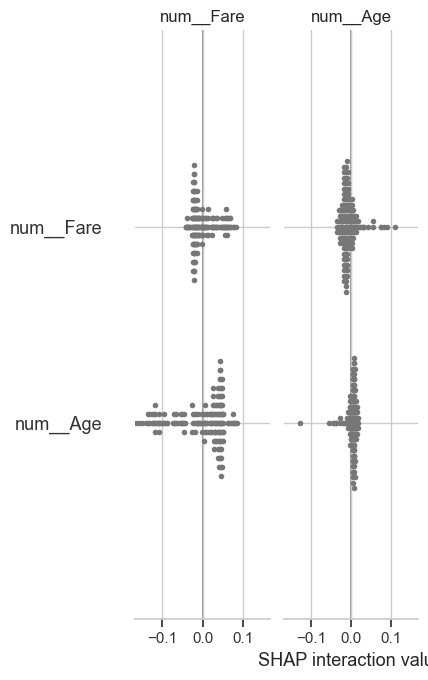

In [357]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

In [359]:
errors = X_test.copy()

errors["Actual"] = y_test.values
errors["Predicted"] = y_pred

errors = errors[errors["Actual"] != errors["Predicted"]]

In [361]:
errors.head(20)

,Pclass,Sex,Age,Fare,Embarked,FamilySize,IsAlone,Title,Actual,Predicted
621,1,male,42.0,52.5542,S,2,0,Mr,1,0
447,1,male,34.0,26.5500,S,1,1,Mr,1,0
192,3,female,19.0,7.8542,S,2,0,Miss,1,0
673,2,male,31.0,13.0000,S,1,1,Mr,1,0
141,3,female,22.0,7.7500,S,1,1,Miss,1,0
235,3,female,28.0,7.5500,S,1,1,Miss,0,1
204,3,male,18.0,8.0500,S,1,1,Mr,1,0
23,1,male,28.0,35.5000,S,1,1,Mr,1,0
362,3,female,45.0,14.4542,C,2,0,Mrs,0,1
772,2,female,57.0,10.5000,S,1,1,Mrs,0,1
